# Section 3: Anomaly Detection for Cyber Threats

This notebook uses the UNSW-NB15 network-flow dataset. An Isolation Forest and a denoising Autoencoder learn only from benign traffic, then detect unusual traffic in validation and test data.

## Setup

In [32]:
import os
import sys

if "google.colab" in sys.modules:
    os.chdir("/content")

In [33]:
%pip install -q joblib matplotlib numpy pandas scikit-learn torch

: 

In [34]:
import hashlib
import importlib.metadata
import json
import platform
import random
import shutil
import sys
import urllib.request
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler
from sklearn.ensemble import IsolationForest
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

: 

### Experiment settings

In [35]:
# Setting the experiment values and random seed.
seed = 42
max_train_normals = 15000
max_validation_per_class = 12000
minimum_validation_recall = 0.60
epochs = 30
early_stopping_patience = 5
noise_std = 0.03

# Finding the main project folder.
def find_project_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "notebooks").is_dir() and (candidate / "docs").is_dir():
            return candidate
    return Path.cwd()

# Choosing the correct folder for Colab or local execution.
in_colab = "google.colab" in sys.modules
root = Path("/content/section_03_workspace") if in_colab else find_project_root()

# Creating folders for the data, models, and results.
data_dir = root / "data/raw/unsw-nb15"
processed_dir = root / "data/processed/section_03"
model_dir = root / "models/section_03"
results_dir = root / "reports/section_03"
for directory in (data_dir, processed_dir, model_dir, results_dir / "metrics", results_dir / "figures"):
    directory.mkdir(parents=True, exist_ok=True)

# Making the experiment results repeatable.
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Limitting the number of CPU threads used by PyTorch.
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))

: 

## Load UNSW-NB15

In [36]:
# Providing backup download links for both dataset files.
dataset_urls = {
    "UNSW_NB15_training-set.csv": [
        "https://huggingface.co/datasets/Mouwiya/UNSW-NB15-small/resolve/main/UNSW_NB15_training-set.csv?download=true",
        "https://media.githubusercontent.com/media/jamshaid120/UNSW_NB15-Complete-dataset/main/UNSW_NB15_training-set.csv",
    ],
    "UNSW_NB15_testing-set.csv": [
        "https://huggingface.co/datasets/Mouwiya/UNSW-NB15-small/resolve/main/UNSW_NB15_testing-set.csv?download=true",
        "https://media.githubusercontent.com/media/jamshaid120/UNSW_NB15-Complete-dataset/main/UNSW_NB15_testing-set.csv",
    ],
}

# Downloading a dataset file only if a valid copy is not already available.
def download_file(destination, urls):
    if destination.exists() and destination.stat().st_size > 1_000_000:
        return
    errors = []

    for url in urls:
        temporary = destination.with_suffix(destination.suffix + ".part")
        try:
            request = urllib.request.Request(url, headers={"User-Agent": "COMP70049-assignment"})
            with urllib.request.urlopen(request, timeout=120) as response, temporary.open("wb") as output:
                shutil.copyfileobj(response, output)
            if temporary.stat().st_size < 1_000_000:
                raise ValueError("Downloaded file is unexpectedly small")
            temporary.replace(destination)
            return
        except Exception as error:
            errors.append(f"{url}: {error}")
            if temporary.exists():
                temporary.unlink()
    raise RuntimeError("Dataset download failed:\n" + "\n".join(errors))

# Downloading the training and testing files.
for filename, urls in dataset_urls.items():
    download_file(data_dir / filename, urls)

# Creating a list of the downloaded files.
data_files = [data_dir / filename for filename in dataset_urls]
dataset_hashes = {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in data_files}

# Loading the files and clean their column names.
raw_parts = []
for path in data_files:
    part = pd.read_csv(path, low_memory=False)
    part.columns = part.columns.astype(str).str.strip().str.lower()
    raw_parts.append((path.name, part))

# Displaying the number of records and columns in each file.
display(pd.DataFrame([
    {"file": name, "records": len(part), "columns": part.shape[1]}
    for name, part in raw_parts
]))

,file,records,columns
0,UNSW_NB15_training-set.csv,175341,45
1,UNSW_NB15_testing-set.csv,82332,45


: 

## Clean and inspect the data

In [37]:
# Using the larger file for development and the smaller file for testing.
raw_parts = sorted(raw_parts, key=lambda item: len(item[1]), reverse=True)
development_name, development = raw_parts[0]
test_name, test = raw_parts[1]

# Cleaning the labels, attack names, and numerical values.
def clean_partition(frame):
    cleaned = frame.copy()
    cleaned = cleaned.drop(columns=[column for column in ["id"] if column in cleaned], errors="ignore")
    cleaned["label"] = pd.to_numeric(cleaned["label"], errors="coerce")
    cleaned = cleaned[cleaned["label"].isin([0, 1])].copy()
    cleaned["label"] = cleaned["label"].astype(int)
    cleaned["attack_cat"] = (
        cleaned["attack_cat"].astype("string").str.strip().replace({"": "Normal"}).fillna("Normal")
    )
    cleaned.loc[cleaned["label"].eq(0), "attack_cat"] = "Normal"
    for column in cleaned.columns.difference(["proto", "service", "state", "attack_cat", "label"]):
        cleaned[column] = pd.to_numeric(cleaned[column], errors="coerce").replace([np.inf, -np.inf], np.nan)
    return cleaned.reset_index(drop=True)

# Cleaning both datasets.
development = clean_partition(development)
test = clean_partition(test)

feature_columns_for_hash = [column for column in development.columns if column not in ["attack_cat", "label"]]

# Counting and removing duplicate records from each dataset.
dev_duplicates = int(development.duplicated(subset=feature_columns_for_hash).sum())
test_duplicates = int(test.duplicated(subset=feature_columns_for_hash).sum())
development = development.drop_duplicates(subset=feature_columns_for_hash).reset_index(drop=True)
test = test.drop_duplicates(subset=feature_columns_for_hash).reset_index(drop=True)

# Removing test records that also appear in the development data.
development_hashes = set(pd.util.hash_pandas_object(development[feature_columns_for_hash], index=False))
test_hashes = pd.util.hash_pandas_object(test[feature_columns_for_hash], index=False)
cross_split_overlap = int(test_hashes.isin(development_hashes).sum())
test = test.loc[~test_hashes.isin(development_hashes)].reset_index(drop=True)

# Creating and saving a summary of the data-cleaning results.
quality_report = {
    "development_file": development_name,
    "test_file": test_name,
    "development_duplicates_removed": dev_duplicates,
    "test_duplicates_removed": test_duplicates,
    "test_rows_overlapping_development_removed": cross_split_overlap,
    "development_records": len(development),
    "test_records": len(test),
    "development_missing_values": int(development.isna().sum().sum()),
    "test_missing_values": int(test.isna().sum().sum()),
}
(processed_dir / "data-quality-report.json").write_text(json.dumps(quality_report, indent=2))

# Displaying the data-quality report and class distribution.
display(pd.Series(quality_report).to_frame("value"))
display(pd.crosstab(development["attack_cat"], development["label"], margins=True))

,value
development_file,UNSW_NB15_training-set.csv
test_file,UNSW_NB15_testing-set.csv
development_duplicates_removed,74301
test_duplicates_removed,28386
test_rows_overlapping_development_removed,1302
development_records,101040
test_records,52644
development_missing_values,0
test_missing_values,0


label,0,1,All
attack_cat,,,
Analysis,0,542,542
Backdoor,0,513,513
DoS,0,3004,3004
Exploits,0,18721,18721
Fuzzers,0,14889,14889
Generic,0,3924,3924
Normal,51815,0,51815
Reconnaissance,0,6422,6422
Shellcode,0,1089,1089


: 

## Create leakage-safe partitions

In [38]:
# Separating and shuffling the benign and attack records.
development_normal = development[development["label"].eq(0)].sample(frac=1, random_state=seed).reset_index(drop=True)
development_attack = development[development["label"].eq(1)].sample(frac=1, random_state=seed + 1).reset_index(drop=True)

# Using only benign records for training.
train_count = min(max_train_normals, max(1, len(development_normal) - max_validation_per_class))
train = development_normal.iloc[:train_count].copy()

# Creating a balanced validation set using benign and attack records.
validation_normal = development_normal.iloc[train_count:train_count + max_validation_per_class].copy()
validation_attack = development_attack.iloc[:max_validation_per_class].copy()
validation = pd.concat([validation_normal, validation_attack], ignore_index=True)

# Shuffling the validation and test records.
validation = validation.sample(frac=1, random_state=seed + 2).reset_index(drop=True)
test = test.sample(frac=1, random_state=seed + 3).reset_index(drop=True)

# Checking that validation and test data contain both classes.
if validation["label"].nunique() != 2 or test["label"].nunique() != 2:
    raise ValueError("Validation and test partitions must both contain benign and attack records")

# Displaying the number of benign and attack records in each dataset.
display(pd.DataFrame([
    {"split": name, "records": len(part), "benign": int(part["label"].eq(0).sum()),
     "attacks": int(part["label"].eq(1).sum())}
    for name, part in (("train", train), ("validation", validation), ("test", test))
]))

,split,records,benign,attacks
0,train,15000,15000,0
1,validation,24000,12000,12000
2,test,52644,33662,18982


: 

## Prepare robust features

In [39]:
# Separating the categorical and numerical features.
categorical_feature_cols = [column for column in ["proto", "service", "state"] if column in train]
numeric_feature_cols = [
    column for column in train.columns
    if column not in [*categorical_feature_cols, "attack_cat", "label"]
]
feature_cols = [*numeric_feature_cols, *categorical_feature_cols]

# Reducing the effect of very large numerical values.
def signed_log(values):
    values = np.asarray(values, dtype=np.float64)
    return np.sign(values) * np.log1p(np.abs(values))

# Filling missing numerical values, transforming them, and scaling them.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("log", FunctionTransformer(signed_log, feature_names_out="one-to-one")),
    ("scaler", RobustScaler(quantile_range=(5.0, 95.0))),
])

# Filling missing categories and converting them into numerical columns.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=False)),
])

# Combining the preprocessing steps and removing constant features.
preprocessor = Pipeline([
    ("columns", ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_feature_cols),
        ("categorical", categorical_pipeline, categorical_feature_cols),
    ], verbose_feature_names_out=False)),
    ("variance", VarianceThreshold()),
])

# Transforming the features and limiting extreme values.
def transform_features(frame, fit=False):
    values = preprocessor.fit_transform(frame[feature_cols]) if fit else preprocessor.transform(frame[feature_cols])
    return np.clip(values, -12.0, 12.0).astype(np.float32)

# Fitingt preprocessing on training data and transform every dataset.
X_train = transform_features(train, fit=True)
X_val = transform_features(validation)
X_test = transform_features(test)

# Storing the validation and test labels.
y_val = validation["label"].to_numpy(np.int64)
y_test = test["label"].to_numpy(np.int64)

# Saving the selected feature names and fitted preprocessor.
feature_names = preprocessor.named_steps["columns"].get_feature_names_out()
feature_names = feature_names[preprocessor.named_steps["variance"].get_support()].tolist()
(processed_dir / "selected-features.json").write_text(json.dumps(feature_names, indent=2))
joblib.dump(preprocessor, model_dir / "feature-preprocessor.joblib")

# Displaying the number of records and features in each dataset.
display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "records": [len(X_train), len(X_val), len(X_test)],
    "features": [X_train.shape[1]] * 3,
}))

,split,records,features
0,train,15000,58
1,validation,24000,58
2,test,52644,58


: 

## Evaluation functions

In [40]:
# Selecting a threshold that meets the minimum attack-recall target.
def select_threshold(labels, scores, minimum_recall=minimum_validation_recall):
    labels, scores = np.asarray(labels), np.asarray(scores)
    fpr, tpr, thresholds = roc_curve(labels, scores)
    eligible = np.flatnonzero(tpr >= minimum_recall)

    # Choose the threshold with the lowest false-positive rate.
    best_index = min(eligible, key=lambda index: (fpr[index], -tpr[index]))
    threshold = float(thresholds[best_index])
    predictions = scores >= threshold
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    
    # Recording the validation recall and false-positive rate.
    return threshold, {
        "policy": "minimum false-positive rate while meeting the validation recall target",
        "minimum_validation_recall": minimum_recall,
        "observed_validation_fpr": float(fp / max(fp + tn, 1)),
        "observed_validation_recall": float(tp / max(tp + fn, 1)),
    }

# Calculating, saving, and displaying the model results.
def show_results(name, labels, scores, threshold, threshold_selection, filename, attack_categories):
    predictions = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    category_frame = pd.DataFrame({
        "attack_category": np.asarray(attack_categories), "label": labels, "detected": predictions,
    })

    # Calculating recall for each attack category.
    attack_frame = category_frame[category_frame["label"].eq(1)]
    category_recall = attack_frame.groupby("attack_category")["detected"].agg(["count", "mean"])
    category_recall = category_recall.rename(columns={"mean": "recall"}).sort_values("recall", ascending=False)
    category_recall.to_csv(results_dir / "metrics" / f"{filename}-attack-recall.csv")

    # Calculating and saving the main evaluation metrics.
    metrics = {
        "threshold": float(threshold), "threshold_selection": threshold_selection,
        "accuracy": float(accuracy_score(labels, predictions)),
        "true_positive_rate": float(tp / max(tp + fn, 1)),
        "false_positive_rate": float(fp / max(fp + tn, 1)),
        "precision": float(precision_score(labels, predictions, zero_division=0)),
        "recall": float(recall_score(labels, predictions, zero_division=0)),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
        "average_precision": float(average_precision_score(labels, scores)),
        "roc_auc": float(roc_auc_score(labels, scores)),
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    }
    (results_dir / "metrics" / f"{filename}.json").write_text(json.dumps(metrics, indent=2))

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    ConfusionMatrixDisplay.from_predictions(labels, predictions, display_labels=["Benign", "Attack"],
                                             cmap="Blues", colorbar=False, ax=axes[0])
    fpr, tpr, _ = roc_curve(labels, scores)

    # Plotting the confusion matrix and ROC curve.
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="grey")
    axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC curve")
    axes[1].legend()

    # Calculating and plotting the precision-recall curve.
    precision, recall, _ = precision_recall_curve(labels, scores)
    axes[2].plot(recall, precision, label=f"AP = {metrics['average_precision']:.3f}")
    axes[2].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve")
    axes[2].legend()

    # Showing how anomaly scores are distributed for benign records.
    axes[3].hist(scores[labels == 0], bins=60, alpha=0.65, density=True, label="Benign")
   
   # Showing how anomaly scores are distributed for attack records.
    axes[3].hist(scores[labels == 1], bins=60, alpha=0.65, density=True, label="Attack")
    axes[3].axvline(threshold, color="black", linestyle="--")
    axes[3].set_title("Anomaly-score distribution")
    axes[3].legend()
    fig.suptitle(name)
    fig.tight_layout()

    # Saving and displaying the complete evaluation figure.
    fig.savefig(results_dir / "figures" / f"{filename}-evaluation.png", dpi=180)
    plt.show()
    display(category_recall)
    return metrics

: 

## Isolation Forest

,max_samples,max_features,validation_roc_auc,validation_average_precision
4,15000,1.00,0.777761,0.786363
3,12000,1.00,0.773586,0.781619
5,12000,0.75,0.772119,0.779424
2,10000,1.00,0.767672,0.778014
1,8192,1.00,0.774570,0.776723
0,4096,1.00,0.774232,0.766714


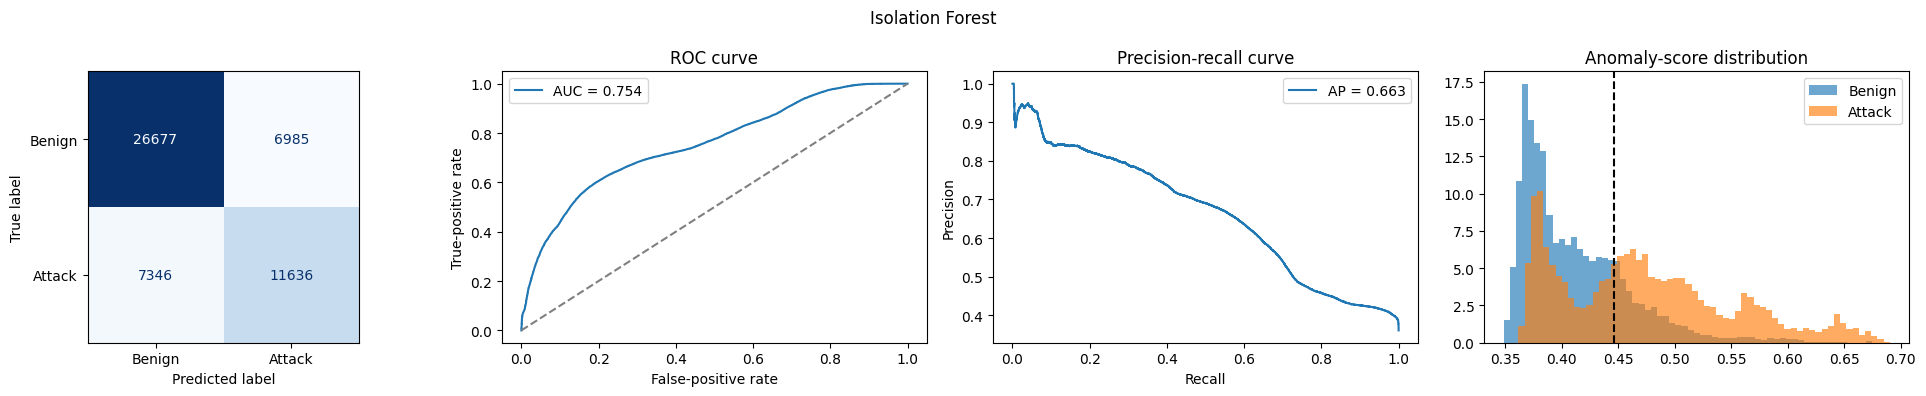

,count,recall
attack_category,,
Generic,3381,0.947944
Worms,43,0.860465
Analysis,294,0.819728
Exploits,7085,0.736627
DoS,1186,0.653457
Shellcode,364,0.450549
Backdoor,70,0.428571
Reconnaissance,2224,0.332734
Fuzzers,4335,0.282584


,value
threshold,0.445887
threshold_selection,{'policy': 'minimum false-positive rate while ...
accuracy,0.727775
true_positive_rate,0.613002
false_positive_rate,0.207504
precision,0.624886
recall,0.613002
f1,0.618887
average_precision,0.663002
roc_auc,0.754275


: 

In [41]:
# Defining the Isolation Forest settings to test.
isolation_candidates = [
    {"max_samples": 4096, "max_features": 1.0},
    {"max_samples": 8192, "max_features": 1.0},
    {"max_samples": 10000, "max_features": 1.0},
    {"max_samples": 12000, "max_features": 1.0},
    {"max_samples": 15000, "max_features": 1.0},
    {"max_samples": 12000, "max_features": 0.75},
]

# Storing the results and tracking the best model.
isolation_search_rows = []
best_isolation = None
best_isolation_key = (-np.inf, -np.inf)

# Training and evaluating every candidate model.
for parameters in isolation_candidates:
    candidate = IsolationForest(
        n_estimators=300, contamination="auto", random_state=seed, n_jobs=-1, **parameters,
    )
    candidate.fit(X_train)

    # Calculating anomaly scores for the validation data.
    candidate_scores = -candidate.score_samples(X_val)

    # Measuring how well the model ranks attacks above benign records.
    candidate_auc = float(roc_auc_score(y_val, candidate_scores))
    candidate_ap = float(average_precision_score(y_val, candidate_scores))
    
    # Saving the candidate's settings and results.
    isolation_search_rows.append({**parameters, "validation_roc_auc": candidate_auc,
                                  "validation_average_precision": candidate_ap})
    candidate_key = (candidate_ap, candidate_auc)
    if candidate_key > best_isolation_key:
        best_isolation_key = candidate_key
        best_isolation = candidate
        best_isolation_parameters = parameters.copy()
# Sorting, saving, and displaying the validation results.
isolation_search = pd.DataFrame(isolation_search_rows).sort_values(
    "validation_average_precision", ascending=False,
)
isolation_search.to_csv(results_dir / "metrics/isolation-forest-validation-search.csv", index=False)
display(isolation_search)

# Selecting the decision threshold using validation scores.
isolation_val_scores = -best_isolation.score_samples(X_val)
isolation_threshold, isolation_threshold_selection = select_threshold(y_val, isolation_val_scores)
isolation_threshold_selection["selected_parameters"] = best_isolation_parameters
isolation_scores = -best_isolation.score_samples(X_test)
isolation_metrics = show_results(
    "Isolation Forest", y_test, isolation_scores, isolation_threshold, isolation_threshold_selection,
    "isolation-forest", test["attack_cat"],
)

# Saving the selected model, preprocessing steps, and threshold.
joblib.dump({"model": best_isolation, "preprocessor": preprocessor,
             "threshold": isolation_threshold, "parameters": best_isolation_parameters,
             "feature_names": feature_names}, model_dir / "isolation-forest.joblib")

# Displaying the final test results.
display(pd.Series(isolation_metrics).drop("confusion_matrix").to_frame("value"))

## Denoising Autoencoder

In [42]:
# Defining the Autoencoder model.
class Autoencoder(nn.Module):
    def __init__(self, feature_count, latent_size=16):
        super().__init__()

        # Reducing the input features to a smaller representation.
        self.encoder = nn.Sequential(
            nn.Linear(feature_count, 128), nn.LayerNorm(128), nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, latent_size),
        )

        # Rebuilding the original features from the smaller representation.
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 64), nn.ReLU(), nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, feature_count),
        )

    # Passing the data through the encoder and decoder.
    def forward(self, values):
        return self.decoder(self.encoder(values))

# Creating data batches for training and evaluation.
def make_loader(features, shuffle=False):
    dataset = TensorDataset(torch.from_numpy(features))
    generator = torch.Generator().manual_seed(seed) if shuffle else None
    return DataLoader(dataset, batch_size=512, shuffle=shuffle, generator=generator)

# Setting up the model to train on the CPU.
device = torch.device("cpu")
ae_model = Autoencoder(X_train.shape[1]).to(device)
optimizer = torch.optim.AdamW(ae_model.parameters(), lr=0.001, weight_decay=0.00001)
loss_fn = nn.SmoothL1Loss(beta=0.5)

# Creating the training batches and select benign validation data.
train_loader = make_loader(X_train, shuffle=True)
X_val_normal = X_val[y_val == 0]

def reconstruction_errors(features):
    ae_model.eval()
    errors = []
    with torch.no_grad():
        for (batch,) in make_loader(features):
            batch = batch.to(device)
            errors.append(((ae_model(batch) - batch) ** 2).cpu().numpy())
    return np.vstack(errors)

# Calculating the average reconstruction loss on benign validation data.
def validation_reconstruction_loss(features):
    ae_model.eval()
    total_loss = 0.0

    # Evaluating the model without updating it.
    with torch.no_grad():
        for (batch,) in make_loader(features):
            batch = batch.to(device)
            total_loss += loss_fn(ae_model(batch), batch).item() * len(batch)
    return total_loss / len(features)

: 

### Train and evaluate

,epoch,training_loss,normal_validation_loss
0,1,0.079138,0.039625
1,2,0.031969,0.023270
2,3,0.018986,0.014240
3,4,0.012736,0.010130
4,5,0.009633,0.007904
5,6,0.007960,0.006526
6,7,0.006751,0.005591
7,8,0.005941,0.004787
8,9,0.005285,0.004229
9,10,0.004796,0.003799


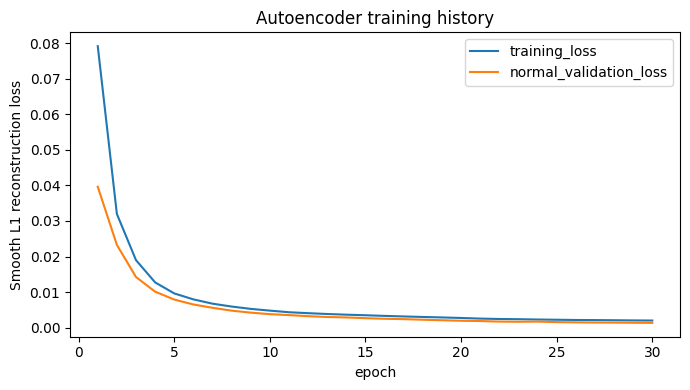

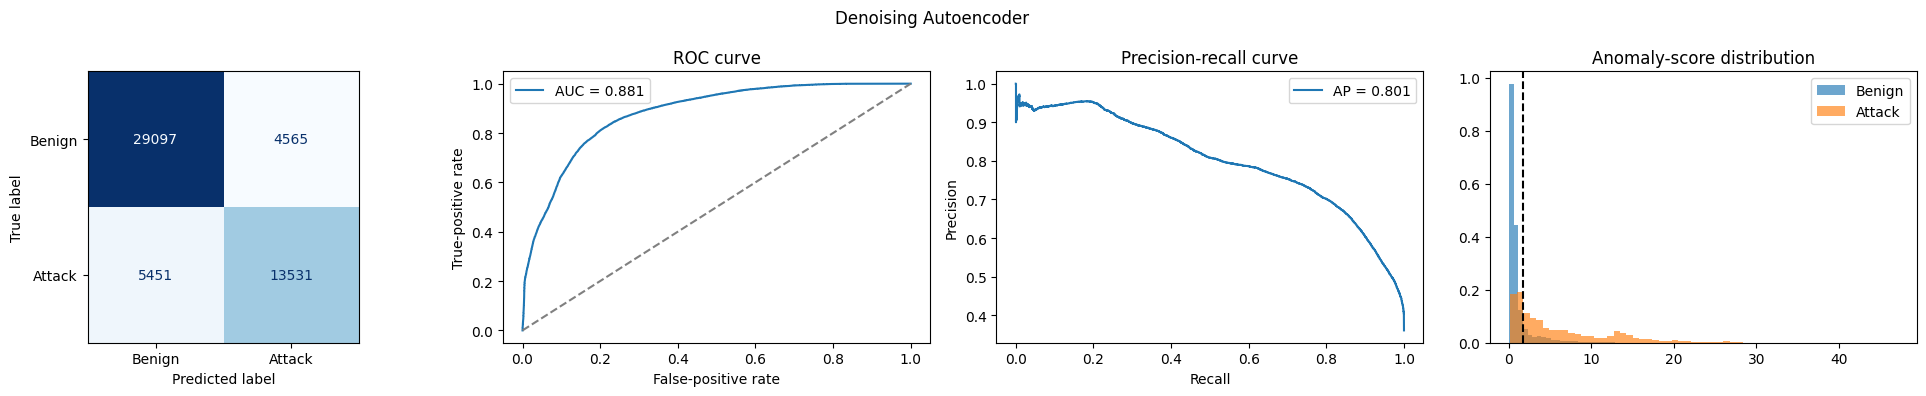

,count,recall
attack_category,,
Analysis,294,1.000000
Generic,3381,0.949127
Exploits,7085,0.864361
Worms,43,0.813953
DoS,1186,0.779933
Backdoor,70,0.600000
Fuzzers,4335,0.467589
Reconnaissance,2224,0.359263
Shellcode,364,0.208791


,value
threshold,1.753262
threshold_selection,{'policy': 'minimum false-positive rate while ...
accuracy,0.809741
true_positive_rate,0.712833
false_positive_rate,0.135613
precision,0.747734
recall,0.712833
f1,0.729867
average_precision,0.801028
roc_auc,0.880792


: 

In [43]:
history = []
best_val_loss = float("inf")
epochs_without_improvement = 0

# Training the Autoencoder for the selected number of epochs.
for epoch in range(1, epochs + 1):
    ae_model.train()
    total_loss = 0.0

        # Training the model using each batch of benign records.
    for (batch,) in train_loader:
        batch = batch.to(device)
        noisy_batch = torch.clamp(batch + noise_std * torch.randn_like(batch), -12.0, 12.0)
        optimizer.zero_grad()
        loss = loss_fn(ae_model(noisy_batch), batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ae_model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item() * len(batch)

    val_loss = validation_reconstruction_loss(X_val_normal)
    history.append({"epoch": epoch, "training_loss": total_loss / len(X_train),
                    "normal_validation_loss": val_loss})

    # Keeping the model with the lowest validation loss.                
    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        chosen_epoch = epoch
        best_state = {name: value.detach().cpu().clone() for name, value in ae_model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    if epochs_without_improvement >= early_stopping_patience:
        break

# Restoring the best model and plot its training history.
ae_model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
history_df.to_csv(results_dir / "metrics/autoencoder-training-history.csv", index=False)
display(history_df)
history_df.set_index("epoch").plot(figsize=(7, 4), title="Autoencoder training history")
plt.ylabel("Smooth L1 reconstruction loss")
plt.tight_layout()
plt.savefig(results_dir / "figures/autoencoder-training-history.png", dpi=180)
plt.show()

# Scaling feature errors so each feature has a similar influence.
normal_feature_errors = reconstruction_errors(X_val_normal)
feature_error_scale = normal_feature_errors.mean(axis=0) + 1e-4

# Converting reconstruction errors into anomaly scores.
def anomaly_scores(features):
    scaled_errors = reconstruction_errors(features) / feature_error_scale
    return np.clip(scaled_errors, 0.0, 100.0).mean(axis=1)

# Selecting the threshold and evaluate the test data.
ae_val_scores = anomaly_scores(X_val)
ae_threshold, ae_threshold_selection = select_threshold(y_val, ae_val_scores)
ae_threshold_selection["chosen_epoch"] = int(chosen_epoch)
ae_scores = anomaly_scores(X_test)
ae_metrics = show_results(
    "Denoising Autoencoder", y_test, ae_scores, ae_threshold, ae_threshold_selection,
    "autoencoder", test["attack_cat"],
)
ae_metrics.update({"best_normal_validation_loss": float(best_val_loss),
                   "chosen_epoch": int(chosen_epoch), "epochs_completed": int(len(history_df)),
                   "device": str(device)})

# Saving the results and trained Autoencoder.
(results_dir / "metrics/autoencoder.json").write_text(json.dumps(ae_metrics, indent=2))
torch.save({"model_state": best_state, "threshold": ae_threshold,
            "feature_error_scale": feature_error_scale, "feature_names": feature_names,
            "latent_size": 16}, model_dir / "autoencoder.pt")
display(pd.Series(ae_metrics).drop("confusion_matrix").to_frame("value"))

## Compare the models

In [44]:
# Comparing the main evaluation results from both models.
metric_names = ["accuracy", "true_positive_rate", "false_positive_rate",
                "precision", "f1", "average_precision", "roc_auc"]
comparison = pd.DataFrame([
    {"model": "Isolation Forest", **{metric: isolation_metrics[metric] for metric in metric_names}},
    {"model": "Denoising Autoencoder", **{metric: ae_metrics[metric] for metric in metric_names}},
])
comparison.to_csv(results_dir / "model-comparison.csv", index=False)

# Recording the dataset, model settings, and software versions.
packages = ["joblib", "matplotlib", "numpy", "pandas", "scikit-learn", "torch"]
run_summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(), "seed": seed,
    "dataset": "UNSW-NB15",
    "dataset_source": "https://research.unsw.edu.au/projects/unsw-nb15-dataset",
    "dataset_sha256": dataset_hashes, "data_quality": quality_report,
    "train_records": len(train), "validation_records": len(validation),
    "test_records": len(test), "features": X_train.shape[1],
    "isolation_forest_parameters": best_isolation_parameters,
    "autoencoder_chosen_epoch": int(chosen_epoch),
    "minimum_validation_recall": minimum_validation_recall, "python": platform.python_version(),
    "platform": platform.platform(),
    "packages": {name: importlib.metadata.version(name) for name in packages},
}
(results_dir / "run-summary.json").write_text(json.dumps(run_summary, indent=2))

# Displaying the model comparison table.
display(comparison.style.format({metric: "{:.4f}" for metric in metric_names}))


# Creating a downloadable results file when running in Colab.
if in_colab:
    export_dir = root / "section_03_export"
    shutil.copytree(results_dir, export_dir / "reports", dirs_exist_ok=True)
    shutil.copytree(model_dir, export_dir / "models", dirs_exist_ok=True)
    shutil.copytree(processed_dir, export_dir / "processed", dirs_exist_ok=True)
    shutil.make_archive("/content/section_03_results", "zip", root_dir=export_dir)
    print("Created /content/section_03_results.zip")

,model,accuracy,true_positive_rate,false_positive_rate,precision,f1,average_precision,roc_auc
0,Isolation Forest,0.7278,0.6130,0.2075,0.6249,0.6189,0.6630,0.7543
1,Denoising Autoencoder,0.8097,0.7128,0.1356,0.7477,0.7299,0.8010,0.8808


Created /content/section_03_results.zip


: 

## Interpretation

Judge the models using ROC AUC and average precision as well as the selected operating point. The threshold is chosen to detect at least 60% of validation attacks while keeping the false-positive rate as low as possible. Review per-attack recall because one overall score can hide weak detection of rare attack families.